In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [120]:
path="<path_hidden>"

In [121]:
df=pd.read_csv(path)

In [122]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [123]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Production,168.0,754.708333,102.204524,553.0,677.75,761.0,824.5,969.0


In [124]:
df.dtypes

,0
Date,object
Production,int64


In [132]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
df = df.set_index('Date')
df.index.freq = 'MS'

In [133]:
df[0:5]

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


<Axes: xlabel='Date'>

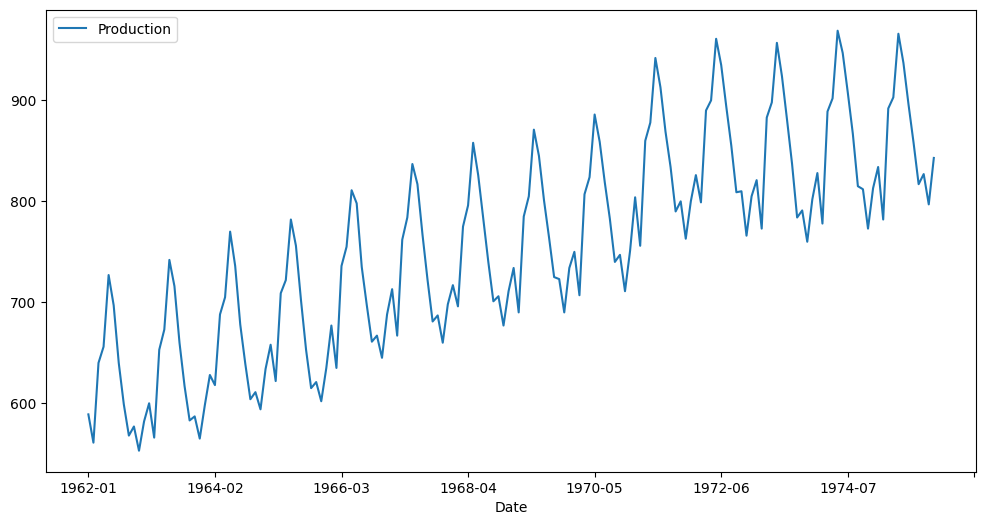

In [34]:
df.plot(figsize=(12,6))

In [134]:
from statsmodels.tsa.seasonal import seasonal_decompose
time_series = pd.Series(df['Production'].values)
time_series.index.freq = 'MS'

results=seasonal_decompose(time_series, period=12)

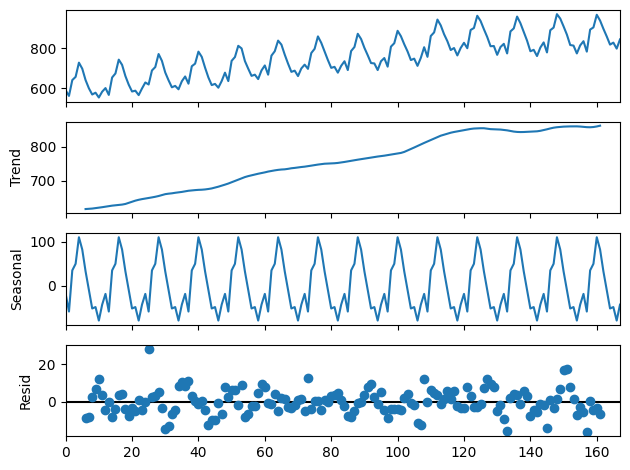

In [135]:
results.plot();

In [136]:
len(df)

168

In [137]:
train_data=df.iloc[:156]
test_data=df.iloc[156:]

<Axes: title={'center': 'Testing data'}, xlabel='Date'>

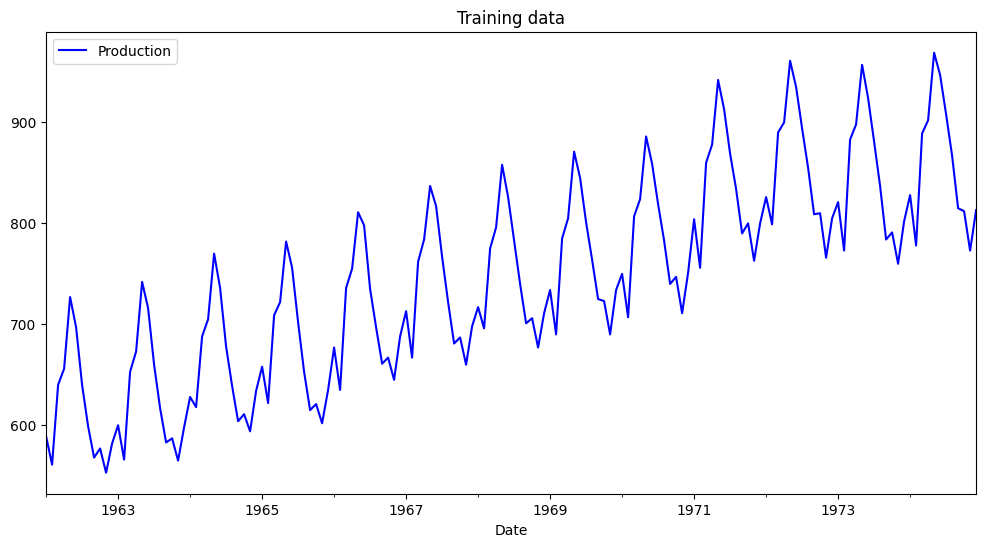

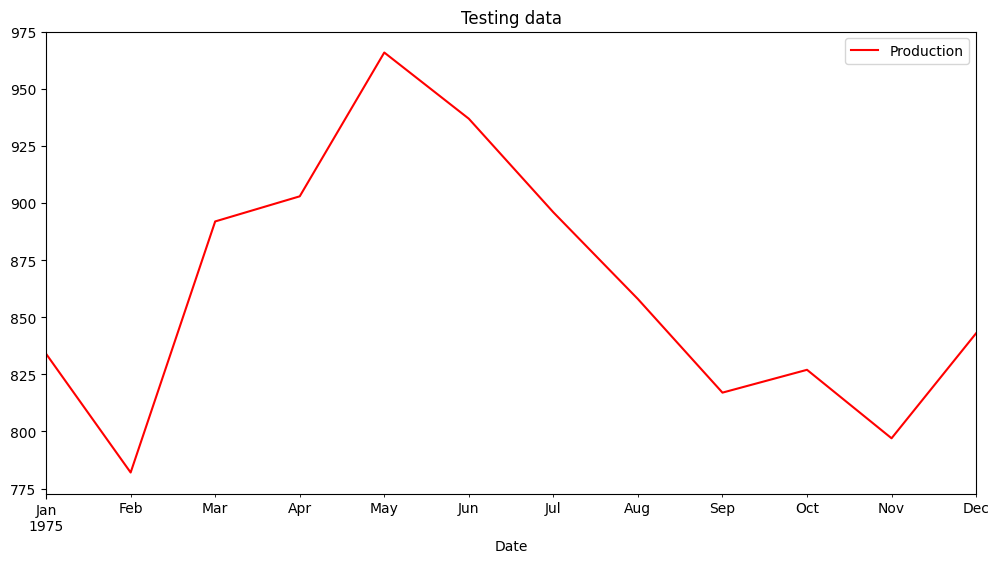

In [138]:
train_data.plot(style='-',color='Blue',figsize=(12,6),title='Training data')
test_data.plot(style='-',color='Red',figsize=(12,6),title='Testing data')

<Axes: xlabel='Date'>

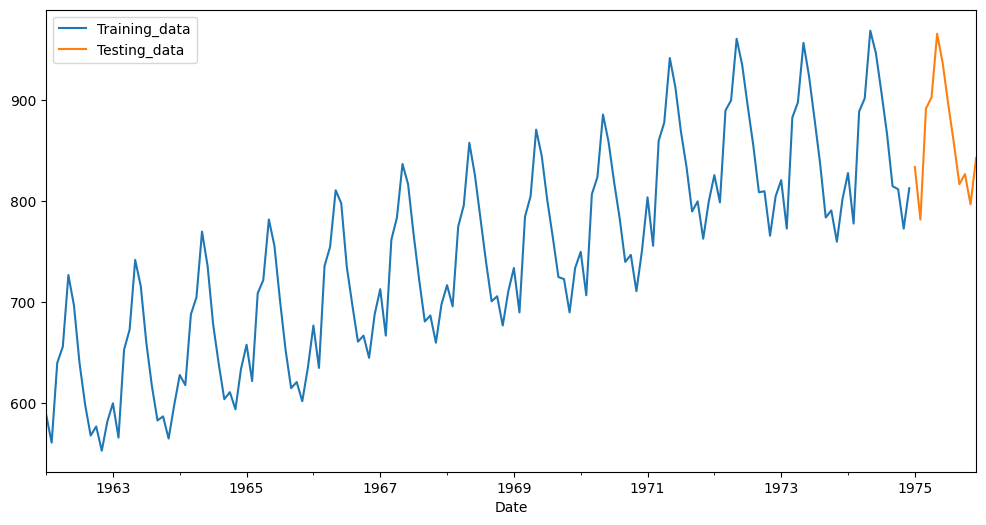

In [139]:
train_data.rename(columns={'Production':'Training_data'}).join(test_data.rename(columns={'Production':'Testing_data'}),how='outer').plot(figsize=(12,6))

In [140]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()

In [141]:
scale_train=scale.fit_transform(train_data)
scale_test=scale.transform(test_data)

In [142]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
n_input=12
n_features=1
generator=TimeseriesGenerator(scale_train,scale_train,length=n_input,batch_size=1)

In [143]:
x,y=generator[1]

In [144]:
print(f"the Input is : {x}\n output is : {y}")

the Input is : [[[0.01923077]
  [0.20913462]
  [0.24759615]
  [0.41826923]
  [0.34615385]
  [0.20913462]
  [0.11057692]
  [0.03605769]
  [0.05769231]
  [0.        ]
  [0.06971154]
  [0.11298077]]]
 output is : [[0.03125]]


#Define Model

In [145]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [146]:
model=Sequential()
model.add(LSTM(100,activation='relu',input_shape=(n_input,n_features)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [147]:
model.add(Dense(1))

In [148]:
model.compile(optimizer='adam',loss='mse')

In [149]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [150]:
model.fit(generator,epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1107
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0268
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0156
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0120
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0074
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0121
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0048
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0076
Epoch 9/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0057
Epoch 10/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0032
Epoch 11/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0030
Epoch 12/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0040
Epoch 13/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0031
Epoch 14/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0045
Epoch 15/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.00

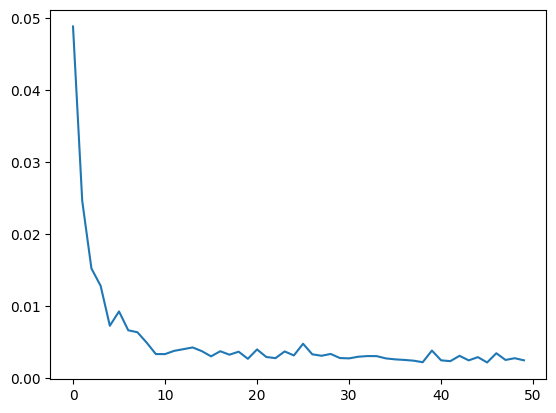

In [151]:
loss_per_epoch=model.history.history['loss']
plt.plot(range(len(loss_per_epoch)),loss_per_epoch)

In [152]:
last_train_batch = scale_train[-12:]

In [153]:
last_train_batch=last_train_batch.reshape((1,n_input,n_features))

In [154]:
model.predict(last_train_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


array([[0.58846736]], dtype=float32)

In [155]:
scale_test[0]

array([0.67548077])

In [158]:
test_predictions = []

first_eval_batch = scale_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))

for i in range(len(test_data)):

    #preiction for first batch
    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred)

    #update the batch and remove the first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [160]:
test_data.head()

,Production
Date,
1975-01-01,834
1975-02-01,782
1975-03-01,892
1975-04-01,903
1975-05-01,966


In [161]:
true_predictions = scale.inverse_transform(test_predictions)

In [163]:
test_data['Predictions'] = true_predictions

/tmp/ipython-input-942/441470350.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predictions'] = true_predictions


<Axes: xlabel='Date'>

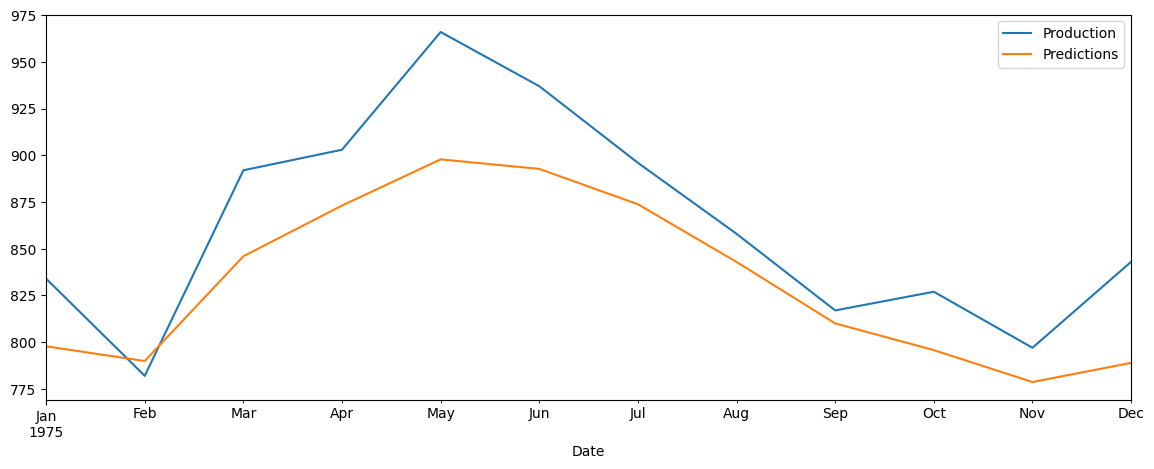

In [165]:
test_data.plot(figsize=(14,5))

In [166]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse=sqrt(mean_squared_error(test_data['Production'],test_data['Predictions']))
print(rmse)

36.5007996647686
